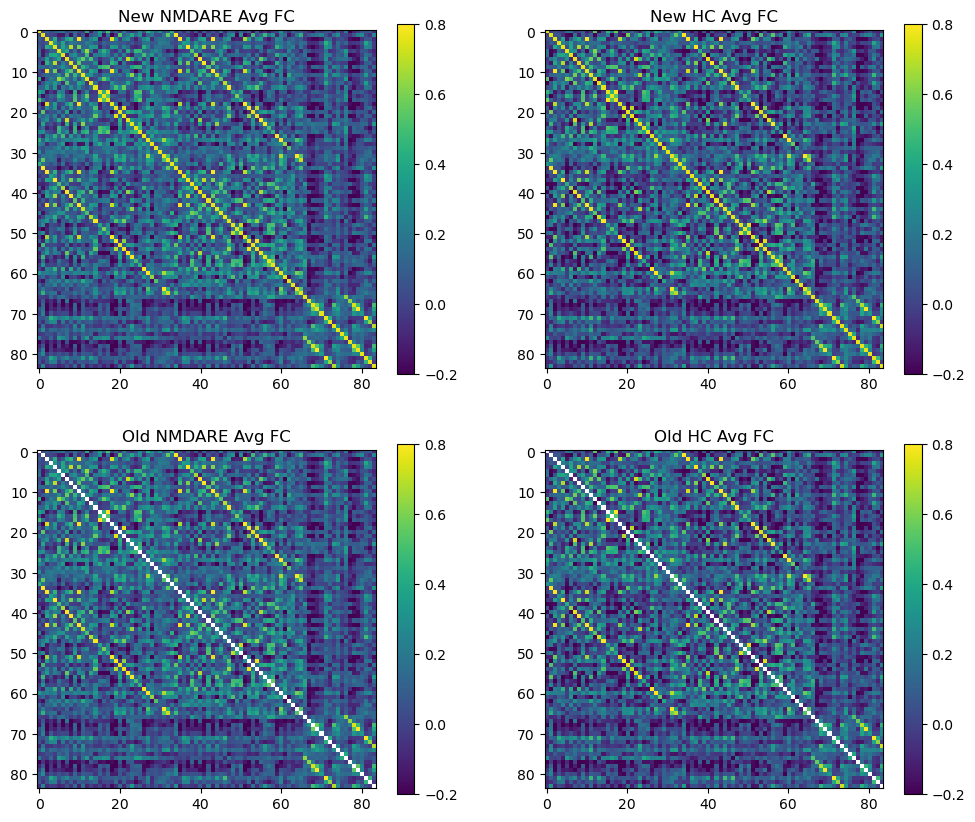

In [7]:
import numpy as np
import matplotlib.pyplot as plt

avg_nmdare_fc = np.loadtxt("out/results/static/avg_nmdare_fc.csv", delimiter=',')
avg_hc_fc = np.loadtxt("out/results/static/avg_hc_fc.csv", delimiter=',')

old_avg_nmdare_fc = np.loadtxt("/Users/brainsimulation/Desktop/NMDARE_FC_analysis/out/DesikanKilliany/avg_nmdare_fc_regr.csv", delimiter=',')
old_avg_hc_fc = np.loadtxt("/Users/brainsimulation/Desktop/NMDARE_FC_analysis/out/DesikanKilliany/avg_hc_fc_regr.csv", delimiter=',')

plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.imshow(avg_nmdare_fc, vmin=-0.2, vmax=0.8, cmap='viridis')
plt.title("New NMDARE Avg FC")
plt.colorbar()
plt.subplot(2, 2, 2)
plt.imshow(avg_hc_fc, vmin=-0.2, vmax=0.8, cmap='viridis')
plt.title("New HC Avg FC")
plt.colorbar()
plt.subplot(2, 2, 3)
plt.imshow(old_avg_nmdare_fc, vmin=-0.2, vmax=0.8, cmap='viridis')
plt.title("Old NMDARE Avg FC")
plt.colorbar()
plt.subplot(2, 2, 4)
plt.imshow(old_avg_hc_fc, vmin=-0.2, vmax=0.8, cmap='viridis')
plt.title("Old HC Avg FC")
plt.colorbar()
plt.show()

In [105]:
np.nanmax(np.abs(avg_nmdare_fc - old_avg_nmdare_fc))
np.nanmax(np.abs(avg_hc_fc - old_avg_hc_fc))

np.float64(2.220446049250313e-16)

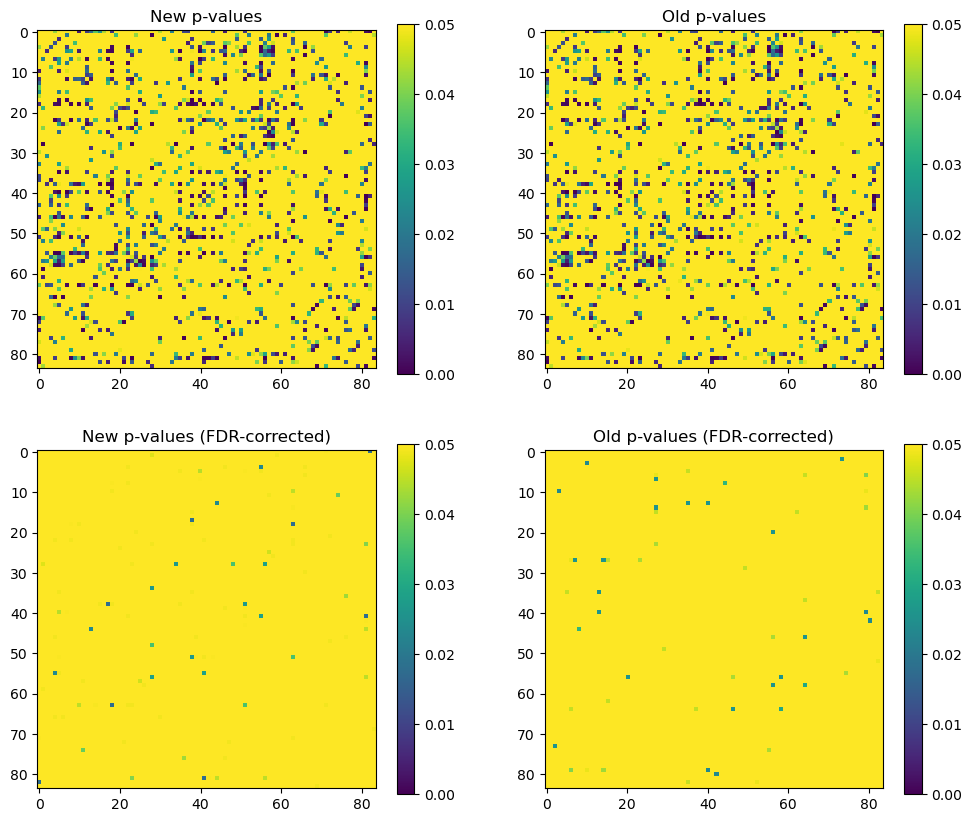

In [73]:
p_vals = np.loadtxt("out/results/static/p_vals.csv", delimiter=',')
old_p_vals = np.loadtxt("/Users/brainsimulation/Desktop/NMDARE_FC_analysis/out/DesikanKilliany/p_vals_unord.csv", delimiter=',')
p_vals_fdr = np.loadtxt("out/results/static/p_vals_fdr.csv", delimiter=',')
old_p_vals_fdr = np.loadtxt("/Users/brainsimulation/Desktop/NMDARE_FC_analysis/out/DesikanKilliany/p_vals_fdr_unord.csv", delimiter=',')
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.imshow(p_vals, vmin=0, vmax=0.05, cmap='viridis')
plt.title("New p-values")
plt.colorbar()
plt.subplot(2, 2, 2)
plt.imshow(old_p_vals, vmin=0, vmax=0.05, cmap='viridis')
plt.title("Old p-values")
plt.colorbar()
plt.subplot(2, 2, 3)
plt.imshow(p_vals_fdr, vmin=0, vmax=0.05, cmap='viridis')
plt.title("New p-values (FDR-corrected)")
plt.colorbar()
plt.subplot(2, 2, 4)
plt.imshow(old_p_vals_fdr, vmin=0, vmax=0.05, cmap='viridis')
plt.title("Old p-values (FDR-corrected)")
plt.colorbar()
plt.show()

Text(0.5, 1.0, 'Difference in FDR-corrected p-values')

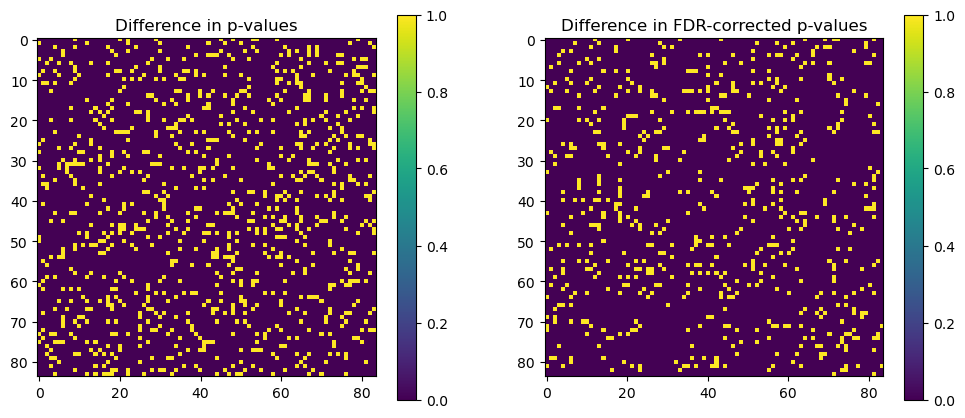

In [127]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(np.abs(p_vals - old_p_vals) > 0.005, cmap='viridis')
plt.colorbar()
plt.title("Difference in p-values")
plt.subplot(1, 2, 2)
plt.imshow(np.abs(p_vals_fdr - old_p_vals_fdr) > 0.7, cmap='viridis')
plt.colorbar()
plt.title("Difference in FDR-corrected p-values")

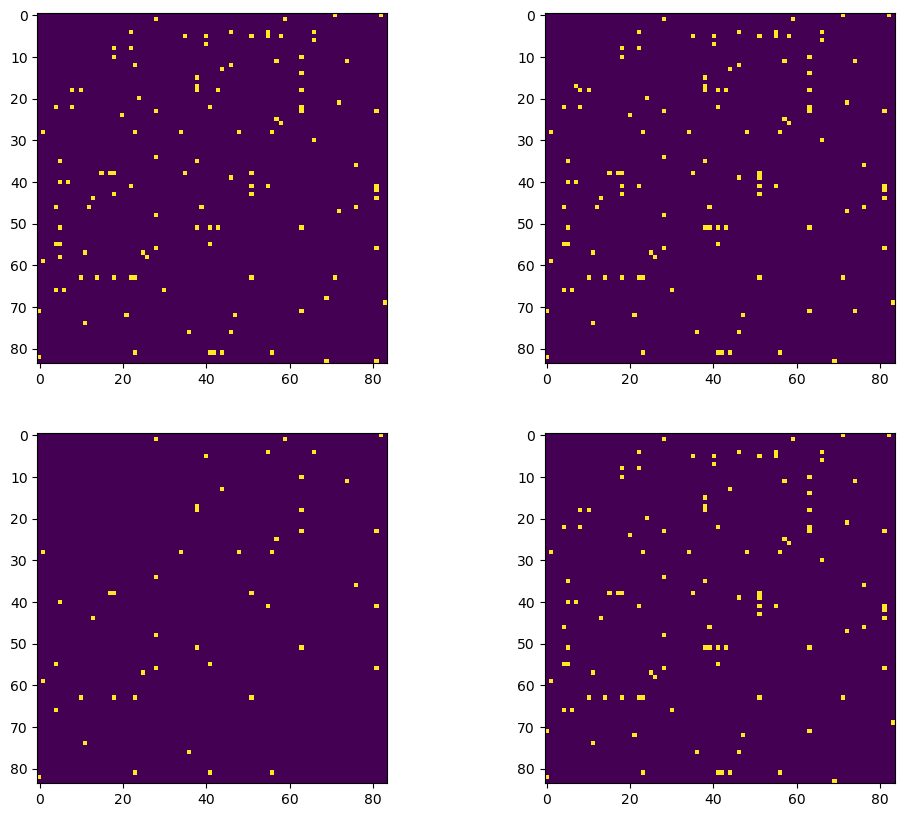

In [97]:
from scipy.stats import false_discovery_control

old_p_vals_fdr = np.loadtxt("/Users/brainsimulation/Desktop/NMDARE_FC_analysis/out/DesikanKilliany/p_vals_fdr_unord.csv", delimiter=',')

on_p_vals_fdr = np.zeros(old_p_vals.shape)
on_p_vals_fdr[np.triu_indices_from(on_p_vals_fdr)] = false_discovery_control(old_p_vals[np.triu_indices_from(old_p_vals)])
on_p_vals_fdr = on_p_vals_fdr + on_p_vals_fdr.T - np.diag(np.diag(on_p_vals_fdr))

no_p_vals_fdr = np.zeros(p_vals.shape)
no_p_vals_fdr[np.triu_indices_from(no_p_vals_fdr)] = false_discovery_control(p_vals[np.triu_indices_from(p_vals)])
no_p_vals_fdr = no_p_vals_fdr + no_p_vals_fdr.T - np.diag(np.diag(no_p_vals_fdr))
np.fill_diagonal(no_p_vals_fdr, 1)

plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.imshow(old_p_vals < 0.001, vmin=0, vmax=0.05, cmap='viridis')
plt.subplot(2, 2, 2)
plt.imshow(p_vals < 0.001, vmin=0, vmax=0.05, cmap='viridis')
plt.subplot(2, 2, 3)
plt.imshow(on_p_vals_fdr < 0.05, vmin=0, vmax=0.05, cmap='viridis')
plt.subplot(2, 2, 4)
plt.imshow(no_p_vals_fdr < 0.05, vmin=0, vmax=0.05, cmap='viridis')

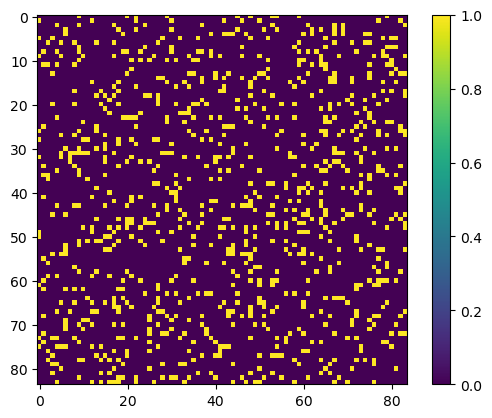

In [117]:
diff_p_vals = np.abs(p_vals - old_p_vals)
plt.imshow(diff_p_vals > 0.005, cmap='viridis')
plt.colorbar()

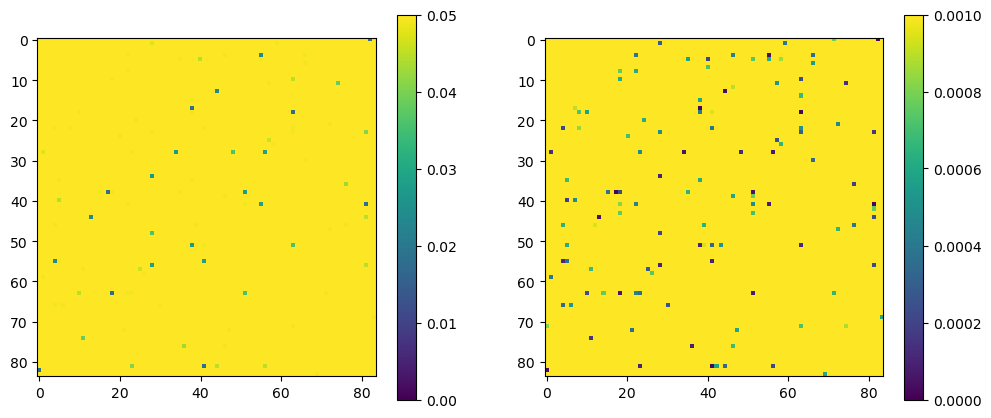

In [110]:
from scipy.stats import false_discovery_control

on_p_vals_fdr = np.zeros(old_p_vals.shape)
on_p_vals_fdr[np.triu_indices_from(on_p_vals_fdr)] = false_discovery_control(old_p_vals[np.triu_indices_from(old_p_vals)])
on_p_vals_fdr = on_p_vals_fdr + on_p_vals_fdr.T - np.diag(np.diag(on_p_vals_fdr))
np.fill_diagonal(on_p_vals_fdr, 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(p_vals_fdr, vmin=0, vmax=0.05, cmap='viridis')
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(p_vals, vmin=0, vmax=0.001, cmap='viridis')
plt.colorbar()
plt.show()

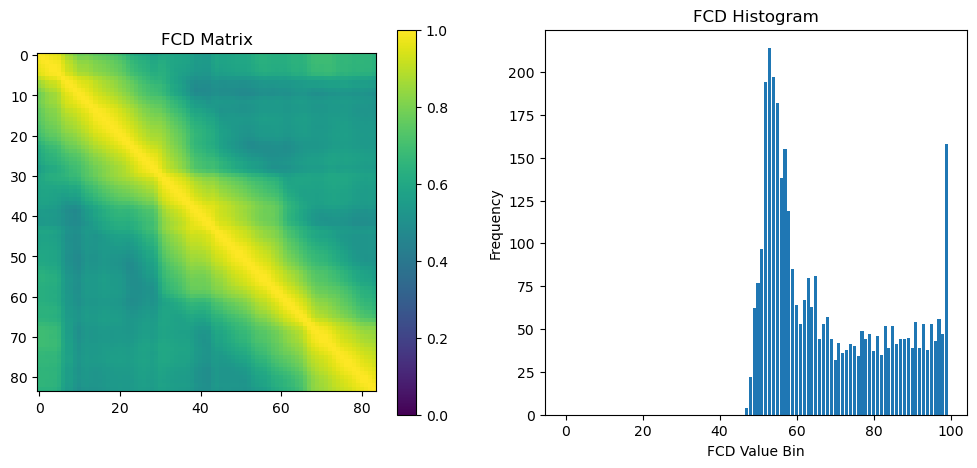

In [39]:
# Load a sample FCD matrix and histogram
fcd = np.loadtxt("out/results/dynamic/sub-LENMDA002/sub-LENMDA002_FCD.csv", delimiter=',')
fcd_hist = np.loadtxt("out/results/dynamic/sub-LENMDA002/sub-LENMDA002_FCD_hist.csv", delimiter=',')
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(fcd, vmin=0, vmax=1, cmap='viridis')
plt.title("FCD Matrix")
plt.colorbar()
plt.subplot(1, 2, 2)
plt.bar(np.arange(len(fcd_hist)), fcd_hist)
plt.title("FCD Histogram")
plt.xlabel("FCD Value Bin")
plt.ylabel("Frequency")
plt.show()

In [61]:
import pickle
import nibabel as nib
import os

rawdir = "/Users/brainsimulation/Desktop/derivatives_dk_T2uniform/derivatives"
subid = "LENMDA002"

window_size = 30
step_size = 1

with open("out/intermediaries/networks/to_delete_network.pkl", "rb") as f:
    to_delete = pickle.load(f)

ts = np.array(nib.load(os.path.join(rawdir, "xcp_d", f"sub-{subid}", "func", f"sub-{subid}_task-rest_space-fsLR_seg-DesikanKilliany_den-91k_stat-mean_timeseries.ptseries.nii")).dataobj)
ts = np.delete(ts, to_delete, 1)

# Calculate the windowed FC matrices
n_windows = len(range(0, ts.shape[0] - window_size, step_size))
windowed_fcs = []
for i in range(0, ts.shape[0] - window_size, step_size):
    window_ts = ts[i:i+window_size, :]
    fc = np.corrcoef(window_ts, rowvar=False)
    np.fill_diagonal(fc, np.nan)
    windowed_fcs.append(fc)



/var/folders/mn/q624n0lj15s26j52tyhh602h0000gn/T/ipykernel_89249/3630394542.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ts = np.array(nib.load(os.path.join(rawdir, "xcp_d", f"sub-{subid}", "func", f"sub-{subid}_task-rest_space-fsLR_seg-DesikanKilliany_den-91k_stat-mean_timeseries.ptseries.nii")).dataobj)


(84, 84)

In [69]:
windowed_fcs[0].shape

(84, 84)

In [68]:
with open("out/results/dynamic/sub-LENMDA002/sub-LENMDA002_windowed_fcs.pkl", "rb") as f:
    windowed_fcs = pickle.load(f)
np.array(windowed_fcs).shape

(230, 84, 84)

In [138]:
with open("/Users/brainsimulation/Desktop/NMDARE_FC_analysis/out/DesikanKilliany/nmdare_fcs_regr.pkl", "rb") as f:
    old_nmdare_fcs_regr = pickle.load(f)
with open("/Users/brainsimulation/Desktop/NMDARE_FC_analysis/out/DesikanKilliany/hc_fcs_regr.pkl", "rb") as f:
    old_hc_fcs_regr = pickle.load(f)

import pandas as pd
demo_data = pd.read_csv("out/intermediaries/demo_data.csv")

excluded = ['RSGK017', 'LENMDA001', 'LENMDA006', 'LENMDA172', 'LENMDA187', 'LENMDA191']
subids = [subid[4:] for subid in os.listdir(os.path.join(rawdir, "xcp_d")) if os.path.exists(os.path.join(rawdir, "xcp_d", f"{subid}", "func", f"{subid}_task-rest_space-fsLR_seg-DesikanKilliany_den-91k_stat-pearsoncorrelation_boldmap.pconn.nii")) and subid[4:] not in excluded]
fcdir = "out/results/static"

nmdare_fcs_regr = []
hc_fcs_regr = []
for subid in subids:
    fc = np.loadtxt(os.path.join(fcdir, f"sub-{subid}", f"sub-{subid}_FC_regr.csv"), delimiter=',')
    if demo_data[demo_data["ID"] == subid]["nmdare"].item() == 1:
        nmdare_fcs_regr.append(fc)
    else:
        hc_fcs_regr.append(fc)

In [148]:
with open("out/results/static/nmdare_fcs_regr.pkl", "wb") as f:
    pickle.dump(nmdare_fcs_regr, f)
with open("out/results/static/hc_fcs_regr.pkl", "wb") as f:
    pickle.dump(hc_fcs_regr, f)

In [139]:
nmdare_fcs_fisher = np.arctanh(nmdare_fcs_regr)
hc_fcs_fisher = np.arctanh(hc_fcs_regr)
old_nmdare_fcs_fisher = np.arctanh(old_nmdare_fcs_regr)
old_hc_fcs_fisher = np.arctanh(old_hc_fcs_regr)

nmdare_diffs = []
for i in range(len(nmdare_fcs_regr)):
    diff = np.abs(nmdare_fcs_regr[i] - old_nmdare_fcs_regr[i])
    nmdare_diffs.append(diff)
print("Max difference in NMDARE FCs:", np.nanmax(nmdare_diffs))

hc_diffs = []
for i in range(len(hc_fcs_regr)):
    diff = np.abs(hc_fcs_regr[i] - old_hc_fcs_regr[i])
    hc_diffs.append(diff)
print("Max difference in HC FCs:", np.nanmax(hc_diffs))

Max difference in NMDARE FCs: 3.0531133177191805e-16
Max difference in HC FCs: 5.273559366969494e-16


In [140]:
from scipy.stats import permutation_test

def statistic(x, y, axis):
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)

p_vals = np.ones(nmdare_fcs_fisher.shape[1:])
stats = np.ones(nmdare_fcs_fisher.shape[1:])
for i in range(nmdare_fcs_fisher.shape[1]):
    for j in range(nmdare_fcs_fisher.shape[2]):
        res = permutation_test([nmdare_fcs_fisher[:, i, j], hc_fcs_fisher[:, i, j]], statistic, permutation_type="independent", n_resamples=100000, rng=13)
        p_vals[i, j] = res.pvalue
        stats[i, j] = res.statistic

on_p_vals = np.ones(old_nmdare_fcs_fisher.shape[1:])
on_stats = np.ones(old_nmdare_fcs_fisher.shape[1:])
for i in range(old_nmdare_fcs_fisher.shape[1]):
    for j in range(old_nmdare_fcs_fisher.shape[2]):
        res = permutation_test([old_nmdare_fcs_fisher[:, i, j], old_hc_fcs_fisher[:, i, j]], statistic, permutation_type="independent", n_resamples=100000, rng=13)
        on_p_vals[i, j] = res.pvalue
        on_stats[i, j] = res.statistic

In [155]:
old_props = pd.read_csv("/Users/brainsimulation/Desktop/NMDARE_FC_analysis/out/DesikanKilliany/graph_properties/graph_properties.csv").drop(columns=["Unnamed: 0"])
new_props = pd.read_csv("out/results/graph_theory/global/global_metrics.csv")

for subid in old_props["subid"]:
    old_sub_props = old_props[old_props["subid"] == subid]
    new_sub_props = new_props[new_props["subid"] == subid]
    print(f"Subject {subid}:")
    old_value = old_sub_props["global efficiency"].item()
    new_value = new_sub_props["global_efficiency"].item()
    print(f"  global efficiency: old={old_value}, new={new_value}, diff={new_value - old_value}")

Subject LENMDA002:
  global efficiency: old=0.6440124132895264, new=0.6516811836088988, diff=0.007668770319372409
Subject RSGK023:
  global efficiency: old=0.6437811853474545, new=0.6552193933433207, diff=0.011438207995866145
Subject LENMDA005:
  global efficiency: old=0.6521062605399991, new=0.6569863871068731, diff=0.004880126566873977
Subject RSGK012:
  global efficiency: old=0.6494810410473102, new=0.6566604078652308, diff=0.0071793668179206405
Subject PROBANDRS002:
  global efficiency: old=0.6492280811557953, new=0.6536392322536926, diff=0.004411151097897248
Subject RSGK015:
  global efficiency: old=0.6094142804986203, new=0.6336546557286687, diff=0.024240375230048405
Subject LEGK010:
  global efficiency: old=0.6507171543316157, new=0.6538275551184355, diff=0.003110400786819789
Subject LEGK019:
  global efficiency: old=0.6497405205236565, new=0.6560692988403863, diff=0.006328778316729844
Subject LENMDA035:
  global efficiency: old=0.6445452806898616, new=0.6499409511888026, diff=0

In [158]:
subid = "LEGK010"
old_fc = pd.read_csv(os.path.join("/Users/brainsimulation/Desktop/NMDARE_FC_analysis/out/DesikanKilliany", f"sub-{subid}", f"sub-{subid}_seg-DesikanKilliany_FC.csv")).values
fc = np.loadtxt(os.path.join("out/results/static", f"sub-{subid}", f"sub-{subid}_FC_raw.csv"), delimiter=',')


In [156]:
with open("out/results/graph_theory/global/sub-LEGK010/sub-LEGK010_avg_clustering.pkl", "rb") as f:
    avg_clustering = pickle.load(f)
avg_clustering

{np.float64(0.1): 0.4394084656109203,
 np.float64(0.15000000000000002): 0.44164127821592297,
 np.float64(0.20000000000000004): 0.42901333084603843,
 np.float64(0.25000000000000006): 0.4318198780066317,
 np.float64(0.30000000000000004): 0.4533539679431329,
 np.float64(0.3500000000000001): 0.47208887894724216,
 np.float64(0.40000000000000013): 0.4982035123563248,
 np.float64(0.45000000000000007): 0.5266411221801516,
 np.float64(0.5000000000000001): 0.5604174631719661,
 np.float64(0.5500000000000002): 0.5941446664986549,
 np.float64(0.6000000000000002): 0.6327080482113503}

In [163]:
with open("out/results/dynamic/FCD_hists.pkl", "rb") as f:
    hists = pickle.load(f)

with open("out/results/dynamic/FCD_hists_regr.pkl", "rb") as f:
    hists_regr = pickle.load(f)

hists

{'LENMDA002': array([   0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,   14.,   70.,  131.,  198.,  275.,
         320.,  389.,  459.,  471.,  559.,  808.,  959.,  893.,  791.,
         673.,  648.,  677.,  812.,  966., 1002.,  893.,  827.,  801.,
         742.,  789.,  866.,  782.,  712.,  594.,  508.,  415.,  337.,
         399.,  332.,  311.,  300.,  243.,  249.,  173.,  157.,  167.,
         131.,  128.,  129.,  158.,  165.,  120.,  127.,  121.,  124.,
         106.,  113.,  116.,  121.,  119.,  116.,  120.,  138.,  108.,
         118.,  119.,  121.,  122.,  127.,  125.,  110.,  131.,  108.,
         116.,  118.,  122.,  110.,  112.,  134.,  122.,  134.,  134.,
         410.]),
 'RSGK023': array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          4.,  32., 100., 219., 227., 210., 188., 163., 182., 266., 331.,
        468., 566., 666., 763.

In [187]:
out_dir = "out/results/graph_theory/global"

with open(os.path.join(out_dir, "global_metric_ps.pkl"), "rb") as f:
    p_vals = pickle.load(f)
with open(os.path.join(out_dir, "global_metric_stats.pkl"), "rb") as f:
    stats = pickle.load(f)

In [188]:
p_vals

{'abs_mean_connectivity': np.float64(0.35111648883511165),
 'avg_clustering': np.float64(0.5972540274597254),
 'global_efficiency': np.float64(0.1914580854191458),
 'modularity': np.float64(0.1122588774112259),
 'assortativity': np.float64(0.5779342206577934),
 'robustness_random': np.float64(0.2173978260217398),
 'robustness_targeted': np.float64(0.4941750582494175)}